首先，假设有一类特定的神经网络架构$\mathcal{F}$，它包括学习速率和其他超参数设置。
对于所有$f \in \mathcal{F}$，存在一些参数集（例如权重和偏置），这些参数可以通过在合适的数据集上进行训练而获得。

为获得目标函数$f^* \in \mathcal{F}$，要先尝试找到$f^*_\mathcal{F}$

例如，给定一个具有$\mathbf{X}$特性和$\mathbf{y}$标签的数据集，我们可以尝试通过解决以下优化问题来找到它：

$$f^*_\mathcal{F} := \mathop{\mathrm{argmin}}_f L(\mathbf{X}, \mathbf{y}, f) \text{ subject to } f \in \mathcal{F}.$$

如果新的函数类
F
′
 并不包含原有函数类
F，即它们是非嵌套的，则更复杂的模型并不能保证更接近真实函数，甚至可能表现更差。相反，在嵌套函数类
𝐹
⊆
𝐹
 的情况下，较大的函数类至少能够表示原函数类中的所有函数，因此可以保证性能不会下降。




对于深度神经网络而言，如果新增的层能够学习恒等映射
f(x)=x，则新模型至少不会比原模型更差，同时还有机会学习到更优的表示，从而降低训练误差。

针对上述问题及解决方法，提出了残差网络resnet

残差块

在传统神经网络中，模型需要直接学习目标映射
f(x)，而在残差网络（ResNet）中，网络改为学习残差映射 f(x)−x，即通过形式 y=F(x)+x 来表示目标函数。

这样的设计使得当理想映射接近恒等映射时，模型只需学习一个接近于零的残差函数，从而显著降低了优化难度。

结构上，残差块由两个 3×3 卷积层组成，每个卷积层后接批量规范化和 ReLU 激活函数。同时，通过跨层连接将输入直接加到输出上，从而实现跳跃连接。为了保证输入与输出可以相加，它们的形状必须一致；当通道数发生变化时，可以通过一个 1×1 卷积对输入进行变换以匹配维度。

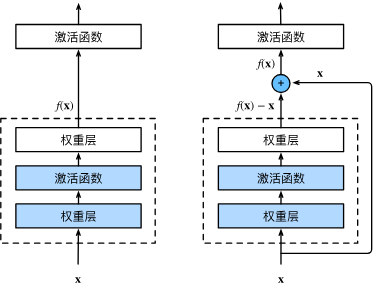

残差块的实现

In [1]:
import torch
from torch import nn
from torch.nn import functional as F


class Residual(nn.Module):
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

此代码生成两种类型的网络：一种是当use_1x1conv=False时，应用ReLU非线性函数之前，将输入添加到输出。 另一种是当use_1x1conv=True时，添加通过1×1卷积调整通道和分辨率。

输入与输出形状一致时

In [2]:
blk = Residual(3,3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

增加输出通道数的同时，减半输出的高和宽

In [3]:
blk = Residual(3,6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

ResNet模型

ResNet的前两层跟之前介绍的GoogLeNet中的一样： 在输出通道数为64、步幅为2的 7×7 卷积层后，接步幅为2的 3×3 的最大汇聚层。 不同之处在于ResNet每个卷积层后增加了批量规范化层。

In [4]:
b1 = nn.Sequential(nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
                   nn.BatchNorm2d(64), nn.ReLU(),
                   nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

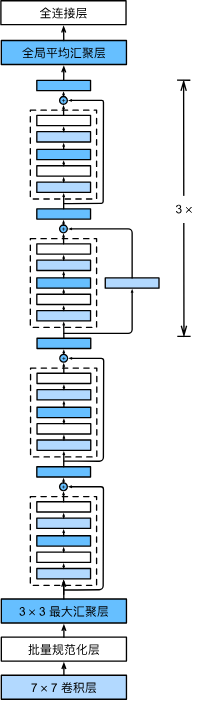

ResNet则使用4个由残差块组成的模块，每个模块使用若干个同样输出通道数的残差块。

第一个模块的通道数同输入通道数一致。之后的每个模块在第一个残差块里将上一个模块的通道数翻倍，并将高和宽减半。

下面实现模块

In [5]:
def resnet_block(input_channels, num_channels, num_residuals,
                 first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels,
                                use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

In [7]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

加入全局平均汇聚层，以及全连接层输出。

In [8]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

每个模块4个卷积层，加上第一个7*7卷积层和最后的全连接层，共18层，ResNet-18

训练模型


In [9]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time

# 超参数
lr, num_epochs, batch_size = 0.05, 10, 256

# 选择设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("training on", device)

# 数据预处理

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

# 下载数据集
train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

# 数据加载器
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 计算准确率
def evaluate_accuracy_gpu(net, data_iter, device):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            correct += (y_hat.argmax(dim=1) == y).sum().item()
            total += y.numel()
    return correct / total

# 训练函数
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        net.train()
        metric_loss = 0.0
        metric_correct = 0
        metric_total = 0
        start = time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()

            metric_loss += l.item() * X.shape[0]
            metric_correct += (y_hat.argmax(dim=1) == y).sum().item()
            metric_total += y.numel()

        train_loss = metric_loss / metric_total
        train_acc = metric_correct / metric_total
        test_acc = evaluate_accuracy_gpu(net, test_iter, device)

        print(f"epoch {epoch + 1}, "
              f"train loss {train_loss:.4f}, "
              f"train acc {train_acc:.4f}, "
              f"test acc {test_acc:.4f}, "
              f"time {time.time() - start:.1f} sec")

# 开始训练
train_ch6(net, train_iter, test_iter, num_epochs, lr, device)

training on cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.8MB/s]


epoch 1, train loss 0.4359, train acc 0.8399, test acc 0.8706, time 10.0 sec
epoch 2, train loss 0.2386, train acc 0.9115, test acc 0.8508, time 8.5 sec
epoch 3, train loss 0.1816, train acc 0.9331, test acc 0.8028, time 8.8 sec
epoch 4, train loss 0.1466, train acc 0.9462, test acc 0.8264, time 8.7 sec
epoch 5, train loss 0.1131, train acc 0.9575, test acc 0.8673, time 8.8 sec
epoch 6, train loss 0.0885, train acc 0.9675, test acc 0.8925, time 8.5 sec
epoch 7, train loss 0.0665, train acc 0.9755, test acc 0.8330, time 8.6 sec
epoch 8, train loss 0.0504, train acc 0.9817, test acc 0.8932, time 8.5 sec
epoch 9, train loss 0.0381, train acc 0.9865, test acc 0.7862, time 8.8 sec
epoch 10, train loss 0.0377, train acc 0.9866, test acc 0.8742, time 8.5 sec


## 练习

1.  :numref:`fig_inception`中的Inception块与残差块之间的主要区别是什么？在删除了Inception块中的一些路径之后，它们是如何相互关联的？


Inception块和残差块的主要区别在于其结构设计和目标不同。Inception块采用多路径并行结构，通过不同大小的卷积核（如1×1、3×3、5×5）以及池化操作同时提取多尺度特征，并将各路径的输出在通道维度上进行拼接，从而增强特征表达能力。而残差块采用单路径结构，并通过跳跃连接将输入直接加到输出上，使网络学习残差映射 F(x)=f(x)−x，从而缓解深层网络中的优化困难问题。

当删除Inception块中的部分路径时，其结构逐渐简化为单路径卷积结构，此时与普通卷积网络类似。如果在此基础上再引入跳跃连接，即将输入与输出相加，则该结构与残差块具有相似形式。

1. 参考ResNet论文 :cite:`He.Zhang.Ren.ea.2016`中的表1，以实现不同的变体。

In [10]:
def build_resnet(blocks):
    # blocks 是一个长度为4的列表，例如 [2,2,2,2] 或 [3,4,6,3]
    b2 = nn.Sequential(*resnet_block(64, 64, blocks[0], first_block=True))
    b3 = nn.Sequential(*resnet_block(64, 128, blocks[1]))
    b4 = nn.Sequential(*resnet_block(128, 256, blocks[2]))
    b5 = nn.Sequential(*resnet_block(256, 512, blocks[3]))

    net = nn.Sequential(
        b1, b2, b3, b4, b5,
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(512, 10)
    )
    return net

实现变体ResNet-34

In [11]:
net34 = build_resnet([3, 4, 6, 3])

In [12]:
train_ch6(net34, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.5140, train acc 0.8242, test acc 0.8392, time 10.8 sec
epoch 2, train loss 0.2398, train acc 0.9119, test acc 0.9101, time 10.6 sec
epoch 3, train loss 0.1847, train acc 0.9317, test acc 0.8812, time 10.6 sec
epoch 4, train loss 0.1474, train acc 0.9454, test acc 0.8644, time 10.7 sec
epoch 5, train loss 0.1164, train acc 0.9569, test acc 0.9069, time 10.6 sec
epoch 6, train loss 0.0946, train acc 0.9656, test acc 0.8894, time 10.6 sec
epoch 7, train loss 0.0749, train acc 0.9722, test acc 0.9142, time 10.7 sec
epoch 8, train loss 0.0549, train acc 0.9800, test acc 0.9073, time 10.6 sec
epoch 9, train loss 0.0515, train acc 0.9811, test acc 0.8988, time 10.7 sec
epoch 10, train loss 0.0407, train acc 0.9856, test acc 0.8690, time 10.7 sec


随着网络深度增加，模型的表达能力增强，但参数量和计算量也随之增大。

1. 对于更深层次的网络，ResNet引入了“bottleneck”架构来降低模型复杂性。请试着去实现它。

In [13]:
class Bottleneck(nn.Module):
    expansion = 4  # 输出通道会变成 num_channels * 4

    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        # 1x1 降维
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=1, stride=1, bias=False)
        self.bn1 = nn.BatchNorm2d(num_channels)

        # 3x3 卷积
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1,
                               stride=strides, bias=False)
        self.bn2 = nn.BatchNorm2d(num_channels)

        # 1x1 升维
        self.conv3 = nn.Conv2d(num_channels, num_channels * self.expansion,
                               kernel_size=1, stride=1, bias=False)
        self.bn3 = nn.BatchNorm2d(num_channels * self.expansion)

        if use_1x1conv:
            self.shortcut = nn.Conv2d(input_channels,
                                      num_channels * self.expansion,
                                      kernel_size=1, stride=strides,
                                      bias=False)
            self.shortcut_bn = nn.BatchNorm2d(num_channels * self.expansion)
        else:
            self.shortcut = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = F.relu(self.bn2(self.conv2(Y)))
        Y = self.bn3(self.conv3(Y))

        if self.shortcut:
            X = self.shortcut_bn(self.shortcut(X))

        Y += X
        return F.relu(Y)

In [14]:
def resnet_block_bottleneck(input_channels, num_channels, num_residuals,
                            first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0:
            if first_block:
                blk.append(Bottleneck(input_channels, num_channels,
                                      use_1x1conv=True, strides=1))
            else:
                blk.append(Bottleneck(input_channels, num_channels,
                                      use_1x1conv=True, strides=2))
        else:
            blk.append(Bottleneck(num_channels * 4, num_channels))
    return blk

In [16]:
def build_resnet50():
    b2 = nn.Sequential(*resnet_block_bottleneck(64, 64, 3, first_block=True))
    b3 = nn.Sequential(*resnet_block_bottleneck(256, 128, 4))
    b4 = nn.Sequential(*resnet_block_bottleneck(512, 256, 6))
    b5 = nn.Sequential(*resnet_block_bottleneck(1024, 512, 3))

    net = nn.Sequential(
        b1,
        b2, b3, b4, b5,
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
        nn.Linear(2048, 10)
    )
    return net

net50 = build_resnet50()


In [17]:
train_ch6(net50, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.7464, train acc 0.7588, test acc 0.6794, time 16.8 sec
epoch 2, train loss 0.3042, train acc 0.8886, test acc 0.8089, time 16.6 sec
epoch 3, train loss 0.2331, train acc 0.9124, test acc 0.8593, time 16.6 sec
epoch 4, train loss 0.1938, train acc 0.9275, test acc 0.8628, time 16.6 sec
epoch 5, train loss 0.1650, train acc 0.9395, test acc 0.8237, time 16.5 sec
epoch 6, train loss 0.1383, train acc 0.9488, test acc 0.8282, time 16.6 sec
epoch 7, train loss 0.1177, train acc 0.9568, test acc 0.7956, time 16.6 sec
epoch 8, train loss 0.0934, train acc 0.9653, test acc 0.8686, time 16.6 sec
epoch 9, train loss 0.0801, train acc 0.9709, test acc 0.8973, time 16.6 sec
epoch 10, train loss 0.0667, train acc 0.9751, test acc 0.9025, time 16.5 sec


对于更深层次的网络，ResNet 引入了 bottleneck 架构来降低模型复杂性。与基本残差块中连续使用两个 3×3 卷积不同，bottleneck 块采用 1×1、3×3、1×1 的三层结构。其中，第一个 1×1 卷积用于降低通道数，中间的 3×3 卷积负责提取空间特征，最后一个 1×1 卷积再将通道数恢复并扩展。

bottleneck 结构能够支持更深层的残差网络，同时相比直接堆叠大量 3×3 卷积更加高效。

1. 在ResNet的后续版本中，作者将“卷积层、批量规范化层和激活层”架构更改为“批量规范化层、激活层和卷积层”架构。请尝试做这个改进。详见 :cite:`He.Zhang.Ren.ea.2016*1`中的图1。

改进残差块类

In [18]:
import torch
from torch import nn
from torch.nn import functional as F

class PreActResidual(nn.Module):
    def __init__(self, input_channels, num_channels,
                 use_1x1conv=False, strides=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(input_channels)
        self.conv1 = nn.Conv2d(input_channels, num_channels,
                               kernel_size=3, padding=1,
                               stride=strides, bias=False)

        self.bn2 = nn.BatchNorm2d(num_channels)
        self.conv2 = nn.Conv2d(num_channels, num_channels,
                               kernel_size=3, padding=1,
                               bias=False)

        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels,
                                   kernel_size=1, stride=strides,
                                   bias=False)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = F.relu(self.bn1(X))
        if self.conv3:
            shortcut = self.conv3(Y)   # v2里常对预激活后的特征做投影
        else:
            shortcut = X

        Y = self.conv1(Y)
        Y = self.conv2(F.relu(self.bn2(Y)))
        Y += shortcut
        return Y

In [19]:
def preact_resnet_block(input_channels, num_channels, num_residuals,
                        first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(PreActResidual(input_channels, num_channels,
                                      use_1x1conv=True, strides=2))
        else:
            blk.append(PreActResidual(
                num_channels if i > 0 or first_block else input_channels,
                num_channels
            ))
    return blk

改进后的ResNet模型

In [20]:
b2_v2 = nn.Sequential(*preact_resnet_block(64, 64, 2, first_block=True))
b3_v2 = nn.Sequential(*preact_resnet_block(64, 128, 2))
b4_v2 = nn.Sequential(*preact_resnet_block(128, 256, 2))
b5_v2 = nn.Sequential(*preact_resnet_block(256, 512, 2))

net_v2 = nn.Sequential(
    b1,
    b2_v2, b3_v2, b4_v2, b5_v2,
    nn.BatchNorm2d(512),   # ResNet v2 常在最后再加一次 BN + ReLU
    nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(512, 10)
)


In [21]:
train_ch6(net_v2, train_iter, test_iter, num_epochs, lr, device)

epoch 1, train loss 0.4353, train acc 0.8548, test acc 0.8404, time 9.0 sec
epoch 2, train loss 0.2320, train acc 0.9152, test acc 0.9007, time 8.6 sec
epoch 3, train loss 0.1811, train acc 0.9330, test acc 0.8954, time 8.6 sec
epoch 4, train loss 0.1415, train acc 0.9480, test acc 0.8948, time 8.6 sec
epoch 5, train loss 0.1089, train acc 0.9607, test acc 0.8900, time 8.6 sec
epoch 6, train loss 0.0831, train acc 0.9704, test acc 0.8964, time 8.6 sec
epoch 7, train loss 0.0640, train acc 0.9776, test acc 0.8742, time 8.8 sec
epoch 8, train loss 0.0464, train acc 0.9840, test acc 0.8969, time 8.9 sec
epoch 9, train loss 0.0346, train acc 0.9885, test acc 0.8757, time 8.8 sec
epoch 10, train loss 0.0274, train acc 0.9909, test acc 0.8933, time 8.7 sec


作者提出了 pre-activation 结构，即将原来的“卷积层—批量规范化层—激活层”改为“批量规范化层—激活层—卷积层”。

相比原始残差块，pre-activation 结构使 shortcut 分支更加接近恒等映射，从而有利于信息和梯度在深层网络中传播。实验中通常可以观察到，这种改进能够使训练更加稳定。

1. 为什么即使函数类是嵌套的，我们仍然要限制增加函数的复杂性呢？

即使函数类是嵌套的，即较大的函数类包含较小的函数类，从理论上可以保证最优解不会变差，但在实际学习过程中仍然需要限制模型复杂性。

首先，过高的复杂度会导致模型容易过拟合训练数据，从而降低在测试数据上的泛化能力。其次，更复杂的模型通常更难优化，可能出现梯度消失或训练不稳定等问题。最后，复杂模型还会带来更高的计算成本和存储开销。